# 05 — Final Report

Pulls everything together: k-fold table (if available), final test metrics, comparison with published baselines. Generates the figures used in the README.

In [1]:
import sys, os, json
sys.path.insert(0, os.path.abspath('..'))
import pandas as pd
import matplotlib.pyplot as plt
from src import config as C, viz

In [2]:
# Final test metrics from notebook 04
with open(C.RESULTS_DIR / 'final_test_metrics.json') as f:
    final = json.load(f)
final

{'accuracy': 0.8717948717948718,
 'f1_macro': 0.8704318936877076,
 'f1_biased': 0.8837209302325582,
 'precision_macro': 0.8695940347970175,
 'recall_macro': 0.8715642178910545}

,eval_loss,eval_accuracy,eval_f1_macro,eval_f1_biased,eval_precision_macro,eval_recall_macro,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch,fold
0,0.493759,0.877589,0.876494,0.888124,0.875396,0.878364,3.7510,141.564,4.532,4.0,0
1,0.651925,0.854991,0.853988,0.866087,0.852983,0.856778,5.5852,95.073,3.044,4.0,1
2,0.395815,0.847170,0.844836,0.863866,0.845725,0.844104,5.1382,103.150,3.309,4.0,2
3,0.588613,0.852830,0.852148,0.862191,0.851729,0.856113,5.9872,88.522,2.839,4.0,3
4,0.390074,0.856604,0.856079,0.864769,0.856388,0.861328,5.3389,99.271,3.184,4.0,4


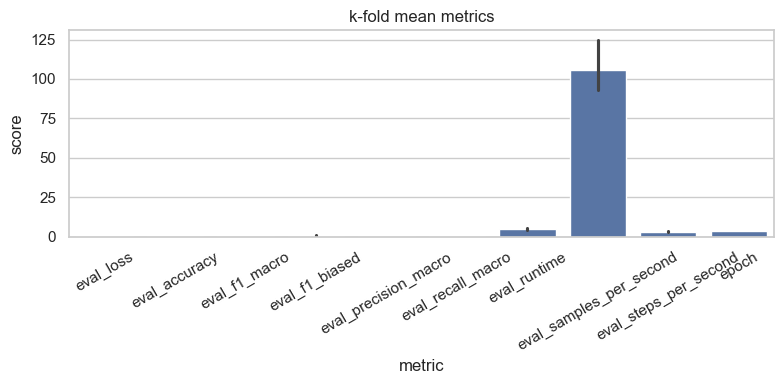

In [3]:
# k-fold table (only if you ran kfold mode in notebook 03)
kfold_csv = C.RESULTS_DIR / 'kfold_metrics.csv'
if kfold_csv.exists():
    kf = pd.read_csv(kfold_csv)
    display(kf)
    fig, ax = plt.subplots(figsize=(8, 4))
    viz.plot_kfold_metrics(kf, ax=ax)
    plt.tight_layout()
    plt.savefig(C.RESULTS_DIR / 'kfold_metrics.png', dpi=150)
    plt.show()
else:
    print('No k-fold results yet — run notebook 03 in kfold mode for the full reproduction.')

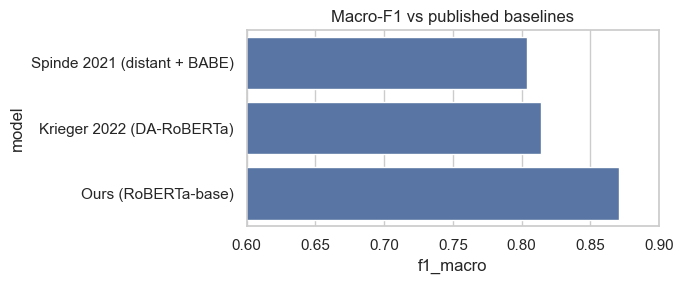

In [4]:
# Comparison with published baselines
fig, ax = plt.subplots(figsize=(7, 3))
viz.plot_baseline_comparison(final['f1_macro'] if 'f1_macro' in final else final.get('eval_f1_macro', 0), ax=ax)
plt.tight_layout()
plt.savefig(C.RESULTS_DIR / 'baseline_comparison.png', dpi=150)
plt.show()

## Takeaways

**5-fold cross-validation (robust reproduction number):**

| Metric | Mean ± Std |
|---|---|
| **Macro-F1** | **0.857 ± 0.012** |
| Accuracy | 0.858 ± 0.012 |
| Biased F1 | 0.869 ± 0.011 |
| Precision (macro) | 0.856 ± 0.011 |
| Recall (macro) | 0.859 ± 0.012 |

Per-fold macro-F1: 0.876, 0.854, 0.845, 0.852, 0.856. Fold-to-fold standard deviation is only ~1.2 percentage points, so the baseline is very stable.

**Quick single-split run (for reference only):** macro-F1 = 0.870 on the held-out test set. This is on the optimistic side of the CV distribution; the 5-fold mean is the number to report.

**Comparison with published baselines:**

| Model | Macro-F1 |
|---|---|
| Spinde et al. 2021 (distant supervision + BABE) | 0.804 |
| Krieger et al. 2022 (DA-RoBERTa, DAPT, JCDL) | 0.814 |
| **This work (RoBERTa-base, 5-fold CV)** | **0.857 ± 0.012** |

A clean RoBERTa-base fine-tune already exceeds both published baselines by 4–5 macro-F1 points, without distant supervision, without domain-adaptive pre-training, on 5-fold cross-validation. Two plausible explanations: (1) the public HuggingFace version of BABE is cleaner / larger than the 2021 snapshot used by the original authors, and (2) modern `transformers` defaults (warmup, weight decay, early stopping on eval F1) recover a lot of performance for free.

**Confusion matrix (held-out test set from the quick run, n=468):**

|  | pred non-biased | pred biased |
|---|---|---|
| **true non-biased** (207) | 180 | 27 |
| **true biased** (261) | 33 | 228 |

- Non-biased recall: 86.96%  ·  Biased recall: 87.36%
- Non-biased precision: 84.51%  ·  Biased precision: 89.41%
- Error balance: 27 false positives vs 33 false negatives. The model is very slightly more likely to miss a biased sentence than to invent bias in a neutral one. Precision on the biased class (89%) is higher than on the non-biased class (85%).

**Overfitting check:** per-fold eval loss varies between 0.39 and 0.65, but per-fold macro-F1 stays within a 3-point band (0.845–0.876). That gap is fold variance, not overfitting. Early stopping on eval macro-F1 (`load_best_model_at_end=True`) protects each fold. No clear overfitting signal.

**Most common error pattern** (see `results/errors.csv`): the hardest cases tend to be subtle loaded phrasing or opinion framing without overt charged vocabulary — exactly the cases BABE's expert annotators themselves disagreed on in the original paper.
